In [1]:
import os
import sys
import pandas as pd
from tqdm import tqdm
from astropy.io import fits
import operator
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import matplotlib

In [2]:
%%bash

cd /home/jen55/urry2023/jen55/DRAGON_CNN && PYTHONPATH=$(pwd) ; export PYTHONPATH && pwd

/home/jen55/urry2023/jen55/DRAGON_CNN


In [3]:
os.chdir("/home/jen55/palmer_scratch/DRAGON_CNN_NEW/DRAGON_CNN")
os.environ["PYTHONPATH"] = os.getcwd()

In [12]:
%%bash

python modules/inference.py \
--model_path='models/new_test3-balanced-dev-nd4o0hes.pt' \
--model_type='dragon' \
--output_path='quasar_test/' \
--data_dir='quasar_test' \
--slug='balanced-dev' \
--n_workers=4 \
--parallel \
--batch_size=16 \
--label_col='classes' \
--n_classes=6 \
--normalize \
--dropout_rate=0.0004 \
--cutout_size=94 \
--channels=1

[2024-07-19 15:04:27,692] Performing pure inference without labels. Using
            column names to infer number of expected outputs.
            Split and Slug values entered will be ignored and
            info.csv will be used.
[2024-07-19 15:04:27,707] Loading images to device...
[2024-07-19 15:04:27,796] Using 1 GPUs.
[2024-07-19 15:04:27,890] Generating PyTorch tensors from FITS files...
100%|██████████| 42476/42476 [01:41<00:00, 417.54it/s]
[2024-07-19 15:06:09,623] Preloading PyTorch tensors before transfer...
100%|██████████| 42476/42476 [02:04<00:00, 340.53it/s]
[2024-07-19 15:08:14,525] Initialization of FITS Dataset Completed.
[2024-07-19 15:08:14,527] Running inference run 1
[2024-07-19 15:08:14,527] Using 1 GPUs.
[2024-07-19 15:08:15,285] Loading model...
[2024-07-19 15:08:15,304] Performing predictions...
[2024-07-19 15:08:15,304] Activating Monte Carlo dropout...
100%|██████████| 2655/2655 [00:10<00:00, 243.67it/s]
[2024-07-19 15:08:26,238] Catalog saved to quasar_tes

In [14]:
df = pd.read_csv(os.path.join(os.getcwd(), "quasar_test/inf_1.csv"))

In [15]:
def cropND(img, bounding):
    start = tuple(map(lambda a, da: a//2-da//2, img.shape, bounding))
    end = tuple(map(operator.add, start, bounding))
    slices = tuple(map(slice, start, end))
    return img[slices]

In [16]:
# Load fits images based on dataframe
label_keys = pd.read_csv("merger_test/labels.csv")
label_dict = label_keys.set_index('key')['value'].to_dict()
label_dict = {v: k for k, v in label_dict.items()}

def load_fits_images(df, data_dir, target_shape=(94, 94)):
    training_images = []
    image_files = []
    true_labels = []
    pred_labels = []
    pred_confidences = []
    mismatched_images = []

    for i in tqdm(range(len(df.index))):
        image_path = os.path.join(data_dir, df["file_name"][i])
        image_class = df["classes"][i] if "classes" in df.columns else -1
        pred_label = df["predicted_labels"][i]
        pred_confidence = df["predicted_confidence"][i]
        
        with fits.open(image_path, memmap=False) as hdul:
            img = hdul[0].data
            if img is not None and img.shape >= target_shape:
                img = cropND(img, target_shape)
                training_images.append(img)
                image_files.append(str(image_path))
                true_labels.append(image_class)
                pred_labels.append(label_dict[pred_label])
                pred_confidences.append(pred_confidence)
            elif img is None:
                img = hdul[1].data
                if img is not None and img.shape >= target_shape:
                    img = cropND(img, target_shape)
                    training_images.append(img)
                    image_files.append(str(image_path))
                    true_labels.append(image_class)
                    pred_labels.append(label_dict[pred_label])
                    pred_confidences.append(pred_confidence)
            
            if image_class != label_dict[pred_label]:
                # print(f"Mismatch between {image_class} and {label_dict[pred_label]}")
                mismatched_images.append(i)
                
    return training_images, image_files, true_labels, pred_labels, pred_confidences, mismatched_images

fits_images, image_files, true_labels, pred_labels, pred_confidences, mismatched_images = load_fits_images(df, data_dir="quasar_test")

100%|██████████| 42476/42476 [05:03<00:00, 139.94it/s]


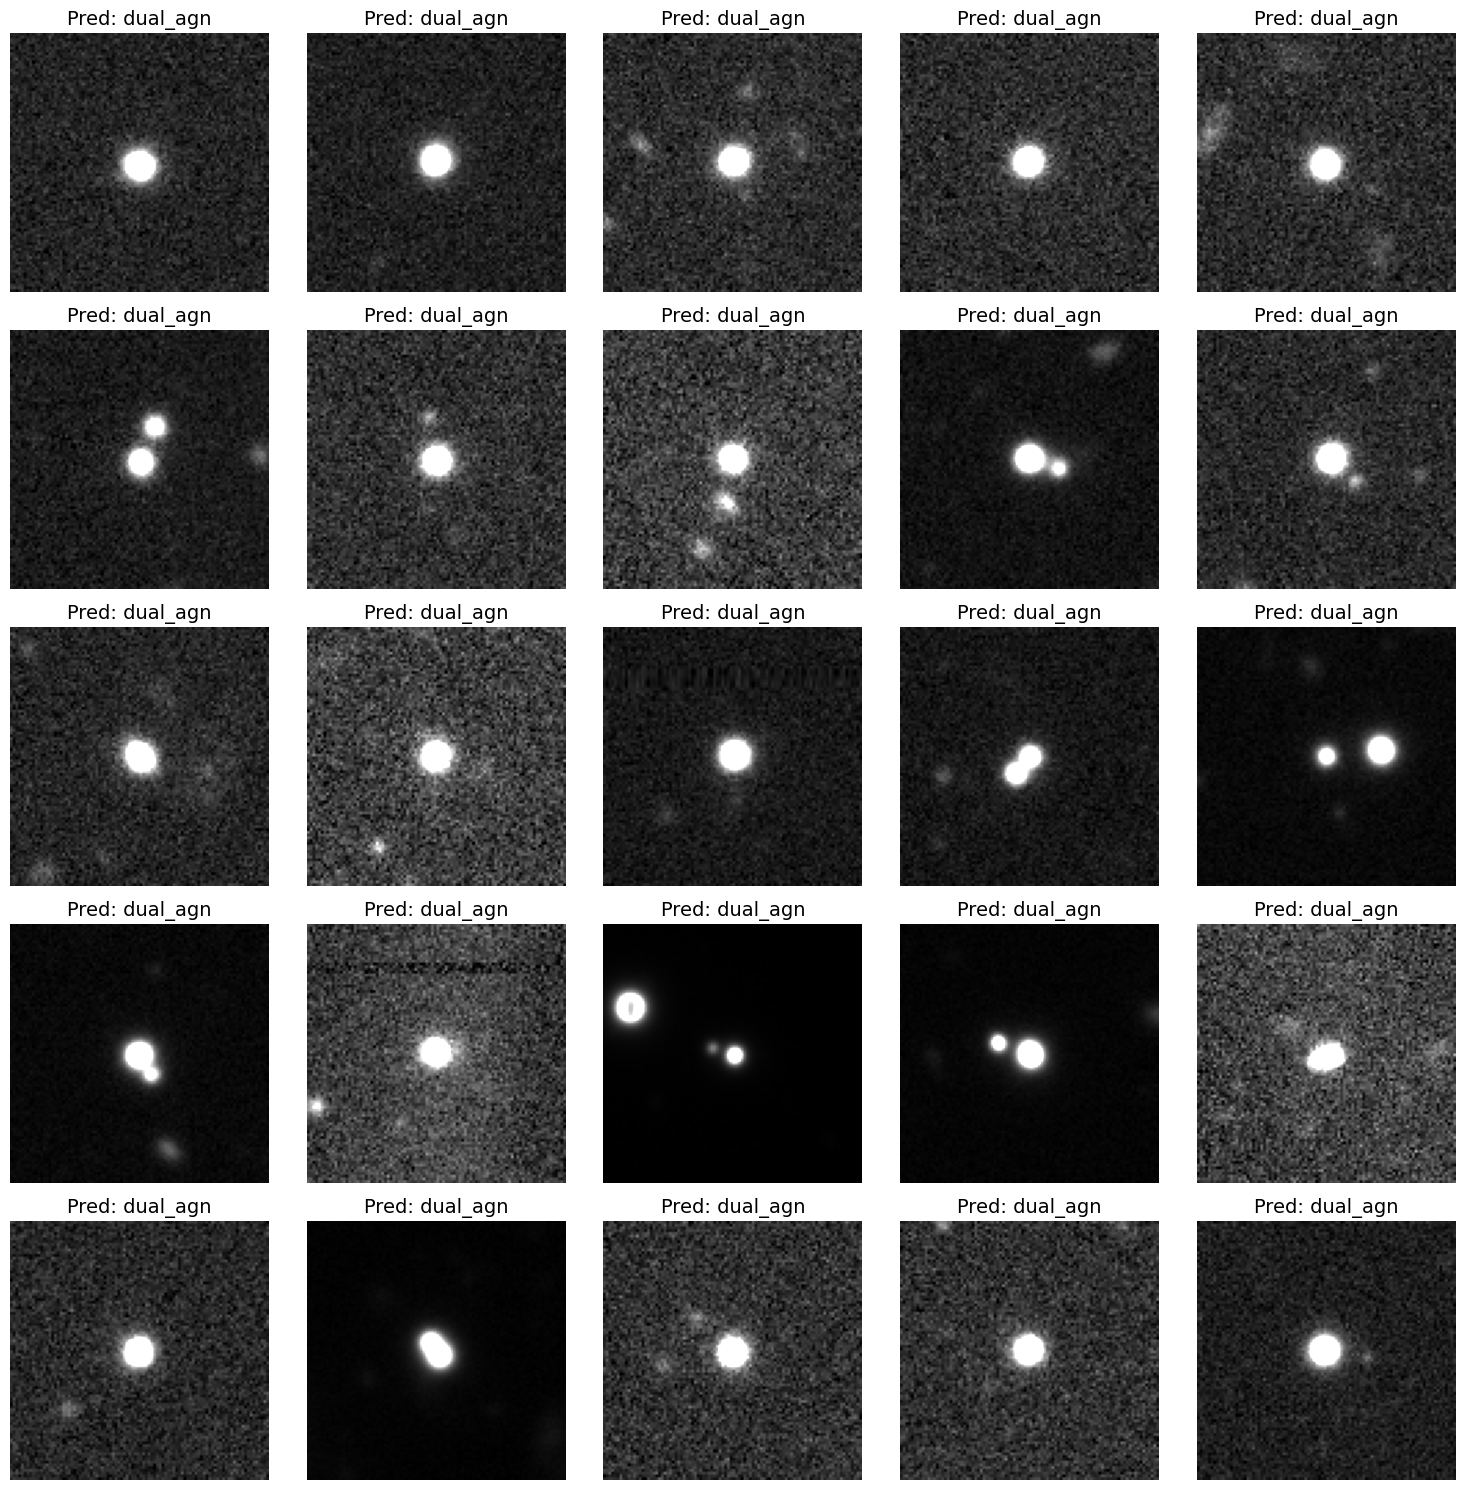

In [17]:
# For all images in general
num_mergers = 0
# criterion = lambda i: agn_merger(i)
criterion = lambda i: (agn_merger(i) and pred_confidences[i] >= 0.8)

def agn_merger(i):
    global num_mergers
    
    if pred_labels[i] == 'dual_agn':
        return True
    elif pred_labels[i] == 'merger' and num_mergers <= 30:
        num_mergers += 1
        return True

    return False

desired_indices = [i for i in range(len(fits_images)) if criterion(i)]
desired_images = [fits_images[i] for i in desired_indices]
desired_image_files = [image_files[i] for i in desired_indices]
desired_pred_labels = [pred_labels[i] for i in desired_indices]
desired_true_labels = [true_labels[i] for i in desired_indices]
desired_pred_confidences = [pred_confidences[i] for i in desired_indices]

num_images = min(len(desired_images), 25)
random_offset_selection = np.random.choice(len(desired_images), size=num_images, replace=False)

# Determine the grid size
grid_size = int(np.ceil(np.sqrt(num_images)))

fig, axes = plt.subplots(grid_size, grid_size, figsize=(15, 15))
axes = axes.flatten()

for i in range(num_images):
    idx = random_offset_selection[i]
    img = desired_images[idx]
    img_name = Path(desired_image_files[idx]).stem
    
    ax = axes[i]
    ax.imshow(img, vmin=np.percentile(img, 1), vmax=np.percentile(img, 99), cmap='gray')
    #ax.set_title(f"Pred: {desired_pred_labels[idx]}, True: {desired_true_labels[idx]}\nConf: {desired_pred_confidences[idx]}\nFile: {img_name}", fontsize=8)
    ax.set_title(f"Pred: {desired_pred_labels[idx]}", fontsize=14)
    ax.axis('off')

# Turn off any unused axes if num_images < grid_size^2
for j in range(num_images, grid_size * grid_size):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [18]:
print(sum(desired_pred_confidences) / len(desired_pred_confidences))

0.8730290081284912


<h1>AGN Cross Checker</h1>
<p>Here, we cross check with the 6 known dual AGN candidates and see which ones were accurately classifed.</p>

In [20]:
csv = 'merger_test/inf_1.csv'
os.chdir('/vast/palmer/scratch/urry/jen55/DRAGON_CNN_NEW/DRAGON_CNN/')
df = pd.read_csv(os.path.join(os.getcwd(), csv))

CANDIDATES = set(["220906_91", "221115_06", "222057_44", "220718_43", "220811_56", "silverman1", "silverman2", "silverman3"])
for _, row in df.iterrows():
    filename = Path(row["file_name"]).stem
    filename = filename.split("_")
    
    cand = "_".join([filename[1], filename[2]]) if len(filename) > 3 else filename[0]
    if cand in CANDIDATES:
        print(cand)
        print(row)
        
print(df["predicted_labels"].value_counts())

220811_56
Unnamed: 0                                                                   632
file_name                      mergerAGN_test/hsc_2626_test_HSC-G/QSO_220811_...
predicted_labels                                                               5
predicted_confidence                                                    0.973691
second_predicted_labels                                                        2
second_predicted_confidence                                           0.00975351
Name: 632, dtype: object
220718_43
Unnamed: 0                                                                  2413
file_name                      mergerAGN_test/hsc_2626_test_HSC-G/UNK_220718_...
predicted_labels                                                               5
predicted_confidence                                                    0.576103
second_predicted_labels                                                        4
second_predicted_confidence                                     

Text(0.5, 0.98, 'Predicted Confidences For All Classifications (Real Data)')

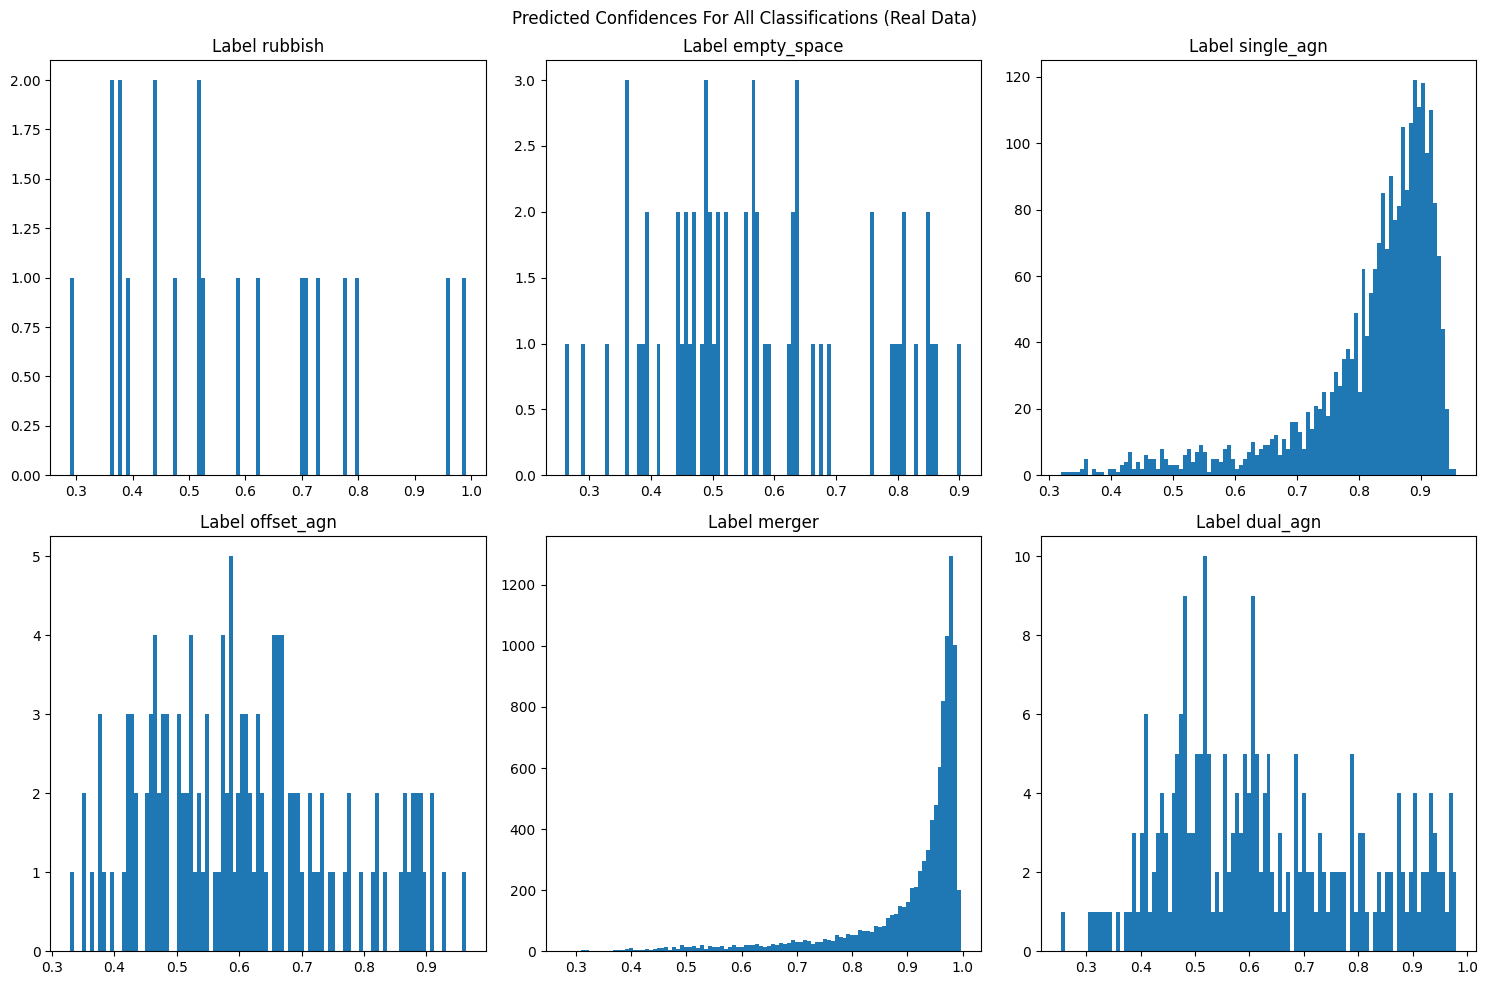

In [31]:
label_keys = pd.read_csv("merger_test/labels.csv")
label_dict = label_keys.set_index('key')['value'].to_dict()
label_dict = {v: k for k, v in label_dict.items()}

n_bins = 100

fig, axs = plt.subplots(2, 3, figsize=(15, 10), tight_layout=True)

for i in range(6):
    data = df[df["predicted_labels"] == i]["predicted_confidence"]
    axs.flat[i].hist(data, bins=n_bins)
    
for ax, label in zip(axs.flat, range(6)):
    ax.set_title(f'Label {label_dict[label]}')
    
fig.suptitle('Predicted Confidences For All Classifications (Real Data)')

Text(0.5, 0.98, 'Predicted Confidences For All Classifications (Quasar Data)')

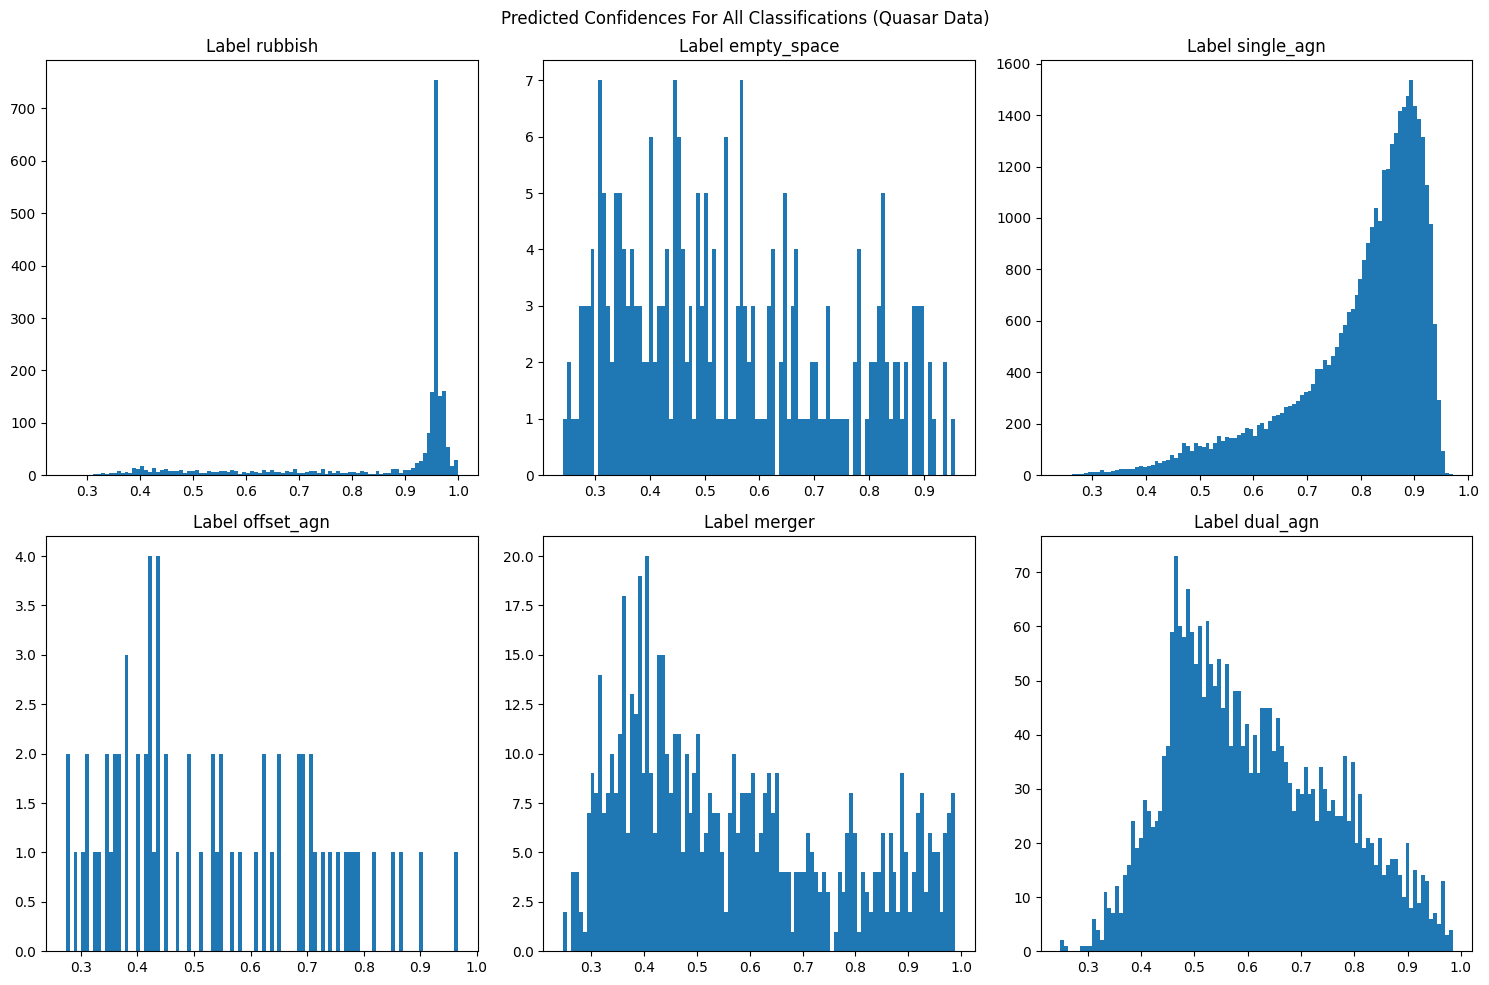

In [32]:
quasar_df = pd.read_csv(os.path.join(os.getcwd(), 'quasar_test/inf_1.csv'))
n_bins = 100
fig, axs = plt.subplots(2, 3, figsize=(15, 10), tight_layout=True)

for i in range(6):
    data = quasar_df[quasar_df["predicted_labels"] == i]["predicted_confidence"]
    axs.flat[i].hist(data, bins=n_bins)
    
for ax, label in zip(axs.flat, range(6)):
    ax.set_title(f'Label {label_dict[label]}')
    
fig.suptitle('Predicted Confidences For All Classifications (Quasar Data)')

<h1>Simulated Plots</h1>

In [18]:
%%bash

python modules/inference.py \
--model_path='models/new_test3-balanced-dev-nd4o0hes.pt' \
--model_type='dragon' \
--output_path='data_preprocessing/training_datasets/' \
--data_dir='data_preprocessing/training_datasets' \
--slug='balanced-dev' \
--n_workers=4 \
--parallel \
--batch_size=16 \
--label_col='classes' \
--n_classes=6 \
--normalize \
--dropout_rate=0.0004 \
--cutout_size=94 \
--channels=1

[2024-07-19 15:32:37,521] Performing pure inference without labels. Using
            column names to infer number of expected outputs.
            Split and Slug values entered will be ignored and
            info.csv will be used.
[2024-07-19 15:32:37,534] Loading images to device...
[2024-07-19 15:32:37,722] Using 1 GPUs.
[2024-07-19 15:32:37,750] Generating PyTorch tensors from FITS files...
100%|██████████| 36000/36000 [00:06<00:00, 5958.18it/s]
[2024-07-19 15:32:43,796] Preloading PyTorch tensors before transfer...
100%|██████████| 36000/36000 [00:35<00:00, 1013.56it/s]
[2024-07-19 15:33:19,407] Initialization of FITS Dataset Completed.
[2024-07-19 15:33:19,408] Running inference run 1
[2024-07-19 15:33:19,408] Using 1 GPUs.
[2024-07-19 15:33:20,160] Loading model...
[2024-07-19 15:33:20,177] Performing predictions...
[2024-07-19 15:33:20,177] Activating Monte Carlo dropout...
100%|██████████| 2250/2250 [00:09<00:00, 241.90it/s]
[2024-07-19 15:33:29,526] Catalog saved to data_pre

Text(0.5, 0.98, 'Predicted Confidences For All Classifications (Simulated Test Data)')

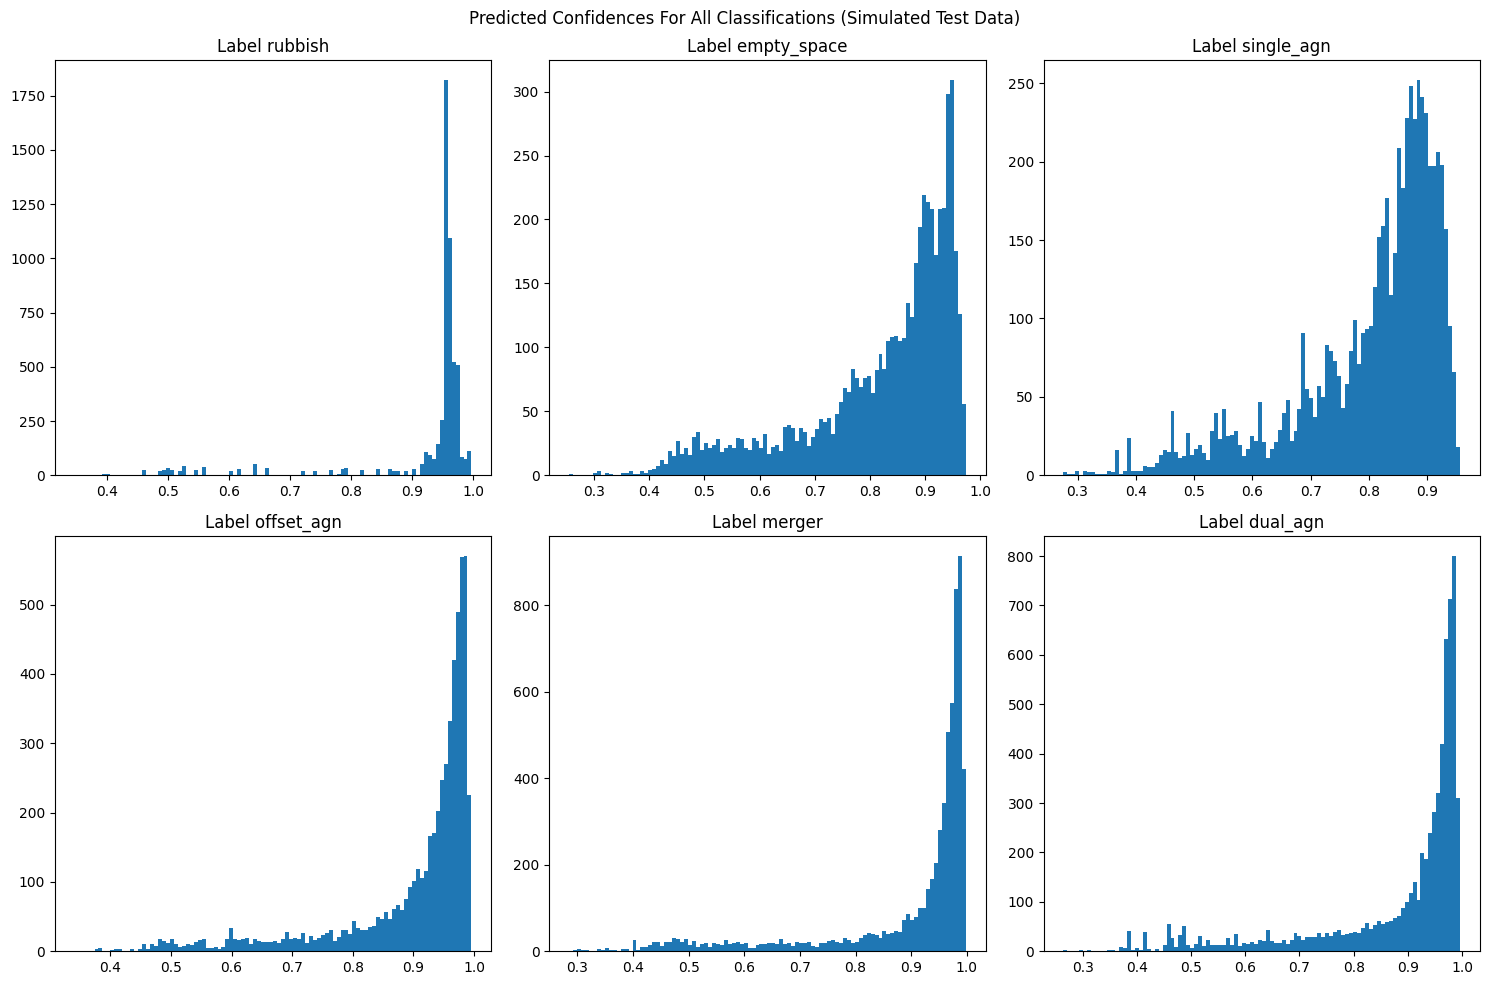

In [33]:
sim_df = pd.read_csv(os.path.join(os.getcwd(), 'data_preprocessing/training_datasets/inf_1.csv'))
n_bins = 100
fig, axs = plt.subplots(2, 3, figsize=(15, 10), tight_layout=True)

for i in range(6):
    data = sim_df[sim_df["predicted_labels"] == i]["predicted_confidence"]
    axs.flat[i].hist(data, bins=n_bins)
    
for ax, label in zip(axs.flat, range(6)):
    ax.set_title(f'Label {label_dict[label]}')
    
fig.suptitle('Predicted Confidences For All Classifications (Simulated Test Data)')